In [1]:
import numpy as np
import pandas as pd
import math
import heapq
import matplotlib.pyplot as plt
from decimal import Decimal
floaterr = 1.0e-8

In [2]:
a = pd.read_csv("./datasets/a280.csv")
a = pd.read_csv("./minidatasets/minitsp.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [3]:
# distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [4]:
# MST 찾기( 프림 알고리즘 사용)
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

In [5]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[4, 7, 9, 10, 14, 15, 16, 18, 20, 28]


In [6]:
next_id = len(distance_matrix)

In [7]:
class blossom:
    def __init__(self, G, Id, nodes=None, edges=None):
        self.Graph = G
        self.Id = Id
        self.Dual = Decimal(0)
        self.Matching = None
        self.Nodes = [] # 블라썸에 포함된 노드들
        self.Edges = [] # 블라썸 원래 노드들
        
        self.Visited = False
        self.Label = None
        self.parent = None

        if nodes != None:
            self.Nodes += nodes
        if edges != None:
            self.Edges += edges
        
    def is_blossom(self):
        if len(self.Nodes) >= 3:
            return True
        return False
        
    def add_node(self, v):
        self.Nodes.append(v)
    def add_edge(self, e):
        self.Edges.append(e)
        
    def distance(self, v):
        return self.Graph.distance(self,v)
        
    def slack(self, v):
        return self.Graph.slack(self,v)
        
    def mark(self): # label visited
        self.Visited = True
        if self.Graph.root == self:
            self.Label = True
            return
        self.Label = not self.parent.Label
    
    def is_containning(self, node):
        if self.Nodes == []: # base case
            if self == node:
                return True
            return False
        
        if x in self.Nodes:
            if x.is_containning(node):
                return True
        return False

In [8]:
# 모든 노드는 블라썸 노드로 생각 할 수 있다.
# 사이즈가 1 이면 일반노드, 3 이상의 홀수 노드이면 블라썸이 되는 것.
# 이떄, 
# 1. 블라썸은 자기에 포함된 노드를 가지고 있어야한다.
# 2. 엣지도 알고 있어야한다.
# 3. 블라썸이 생길떄 전체 그래프에서 노드와 엣지를 추가/삭제 해야함.

# 그리고 트리를 관리해야함. 트리는 루트를 알고 있어야하고, 트리의 구성을 알기위해서 어떻게 연결되었는지 찾을 수 있어야함. 맞나?
# 한놈을 고르고 그놈이 augment 될떄까지 그놈만 패면 되니까.
# 트리를 관리하지 말고 한놈을 잡고 그놈이 매칭될때 까지 패면 될듯함.

# lifting 과 expand 구분하기
# augment  할떄는 lifting 만 하면 됌 
# lifting 은 구멍을 v 가 되게 matching 을 구성하게 하자, 지금 블라썸에 1개는 매칭이 없는 상황임 그게 v 가 되게하면 나중에 expanding 할때 매칭 없는놈이랑
# 이어주기만 하면 됌.


    
    
# 트리를 그래프가 하나만 가지고 있고
# 트리는 루트만 가지고 있음 그리고
# 각 노드는 자식과 부모를 알고 있다.
# priaml operation 은 여기에다가 하면 될듯

class blossomgraph:
    def __init__(self, indices):
        self.nodes = [ blossom( self, Id ) for Id in indices ]  # nodes 먼저 생성하고
        self.edges = [] # (u,v, weight, original e) 
        self.root = None
        
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                self.edges.append( ( n1, n2, Decimal( format(distance_matrix[n1.Id][n2.Id], '.15f')), None ) ) # (u,v, weight, e) # e 는 원래 랑 대응되는 놈이 있는지

        self.alt_tree = [] # 트리 안에 있는 노드만 기록
        
    def distance(self, u, v):
        for n1, n2, w, e in self.edges:
            if (u,v) == (n1,n2) or (v,u) == (n1,n2):
                return w
        return Decimal(-1)
        
    def slack(self, u, v):
        return self.distance(u,v) - u.Dual - v.Dual
        
    def tightnode(self,u):
        return [ node for node in self.nodes if self.slack(u, node) <= 1.0e-8 and self.slack(u, node) >= -1.0e-8  ]

    def init_nodes(self):
        for node in self.nodes:
            node.Visited = False
            node.Label = None
            node.parent = None

    def find_edge(self, edges, u, v ): # u ,v 연결하는 엣지 리턴함 순서 맞춰서 ( 엣지 셋 에서 u v 연결하는 거 찾아버림림)
        for n1, n2, w, e in edges:
            if (u,v) == (n1,n2):
                return (n1,n2,w,e)
            elif (u,v) == (n2,n1):
                return (n2,n1,w,e)
            
    #일단 u v 연결하는 엣지를 찾아버림, 그리고 그 엣지의 원래 엣지를 찾아. 그다음에 u 에 포함되는거 찾고 v 에 포함되는 거 찾고, 그리고 나서 뭐하냐
    # 
    
    def Lifting(self, blossom, e): #블라썸을 엣지 e 와 연결되게 lifting한다. connect 로 해야함
        a1,a2,a3,a4 = e
        print(blossom.Id, a1.Id,a2.Id,a3,a4)

        target = None
        if e[3] == None:
            o = e
        else:
            o = e[3]

        for node in blossom.Nodes:
            if node.is_containning(o[0]):
                target = node
                break
            if node.is_containning(o[1]):
                target = node
                break

        if target == None:
            print("target is None")
            return
        else:
            print( target.Id, "is target")

        while blossom.Nodes[0] != target:
            blossom.Nodes.append( blossom.Nodes.pop(0) )

        for idx in range(1, len(blossom.Nodes) -1 , 2):
            self.connect( blossom.Nodes[idx], blossom.Nodes[idx+1], blossom.Edges )
        blossom.Nodes[0].Matching = None
        print("lifting", blossom.Id, "to", target.Id)
        

    def connect(self,u,v, edges): #u, v 
        u.Matching = v
        v.Matching = u
        
        curedge = self.find_edge(edges, u, v) # (u,v, w, e)
        n1, n2, w, e = curedge

        if u.is_blossom() and v.is_blossom():
            print(u.Id, v.Id, "blossom")
            self.Lifting( u, curedge )
            self.Lifting( v, curedge )
        elif u.is_blossom(): # u 만 블라썸이야
            print(u.Id, "blossom")
            self.Lifting( u, curedge )
        elif v.is_blossom():
            print(v.Id, "blossom")
            self.Lifting( v, curedge)


    def find_cycle(self, u,v): # 인접하는 노드 끼리 인덱스 이웃하게 넣기
        upath =[]
        vpath = []
        upath.append(u)
        vpath.append(v)
        
        cur = u
        while cur.parent != None:
            upath.append( cur.parent )
            cur = cur.parent

        cur = v
        while cur.parent != None:
            vpath.append( cur.parent )
            cur = cur.parent

        cycle = []
        for uindex in range(len(upath)):
            if upath[uindex] in vpath:
                break
        target = upath[uindex]
        cur = u
        while cur != target:
            cycle.append( cur )
            cur = cur.parent

        cycle.append(target)
        
        cur = v
        while cur != target:
            cycle.insert(0, cur )
            cur = cur.parent

        return cycle, target.parent

    def SHRINK(self,Cycle): # 내부 엣지는 숨기기만 하면 되고, 외부와 연결된 엣지는 숨기고, dual 값 뺴서 외부와 연결시켜야함
        #그리고 새로운 블라썸 리턴턴
        cycle , target = Cycle
        global next_id
        newblossom = blossom(self, next_id, cycle)
        next_id += 1
        newblossom.Label = True
        newblossom.parent = target
        newblossom.Matching = target
        
        if self.root in cycle:
            self.root = newblossom
        
        self.nodes.append(newblossom)
        for node in cycle:
            self.nodes.remove(node)

        deledges = []
        addedges = []

        for edge in self.edges: #엣지부터 처리

            u,v,w,o = edge
            if o == None:
                o = edge
            else:
                o = edge[3]

            uin = u in cycle
            vin = v in cycle
            if uin and  vin: #내부 엣지
                newblossom.add_edge( edge ) #블라썸에 저장해두고
                deledges.append(edge)
            elif uin and not vin: #외부 엣지임
                newblossom.add_edge(edge)                           #블라썸에 저장해두고
                deledges.append(edge)
                addedges.append( ( newblossom, v, w - u.Dual ,o) )    #바꿔서 그래프에 추가
            elif not uin and vin:
                newblossom.add_edge(edge)                           #블라썸에 저장해두고
                deledges.append(edge)
                addedges.append( ( newblossom, u, w - v.Dual, o) )    #바꿔서 그래프에 추가
                

        for e in deledges:
            self.edges.remove(e)
        for e in addedges:
            self.edges.append(e)

        # for node in self.nodes:
        #     if newblossom == node:
        #         continue
        #     if node.Matching in cycle:
        #         node.Matching.Matching = None
        #         self.connect(node, newblossom, self.edges)

        for node in cycle: # 외부 - 블라썸 에서 외부의 매칭은 블라썸으로 블라썸 내부의 매칭은 none으로
            if node.Matching in cycle:
                continue
            else:
                #node 는 연결 할 놈인거임 매칭이 없을 수 도 있고 있을 수 도 있고
                if node.Matching != None:
                    node.Matching.Matching = newblossom
                    node.Matching = None
                else:
                    node.Matching = None

        for node in cycle:
            self.alt_tree.remove(node)
        self.alt_tree.append(newblossom)

        while newblossom.Nodes[0].Matching != None:
            newblossom.Nodes.append( newblossom.Nodes.pop(0) )

        for n in self.nodes:
            print(newblossom.Id, n.Id, self.slack(newblossom, n))
        return newblossom

    def EXPAND(self, blossom): #가지고 있던거 밖으로 다 던지고, 그래프에 blossom 적인거 다 지우면 됌.
        #원복

        for node in blossom.Nodes:
            self.nodes.append(node)
        for edge in blossom.Edges:
            self.edges.append(edge)

        self.nodes.remove(blossom)
        dellist=[]
        for e in self.edges:
            n1,n2,w, o = e
            if n1 == blossom or n2==blossom:
                dellist.append( e )
        for x in dellist:
            self.edges.remove(x)

        blossom.Nodes[0].Matching = blossom.Matching
        blossom.Matching.Matching = blossom.Nodes[0]

    def bfs(self, root): #bfs 하고 cycle 생기면 블라썸 만들어버리는 것 까지. grow augment shrink expand
        self.init_nodes()
        self.alt_tree.clear()
        queue = []
        root.mark()
        queue.append(root)
        self.alt_tree.append(root)
        print("root id : ", root.Id)
        while queue:
            curnode = queue.pop(0) # + 인 애들임
            print("curnode : ",curnode.Id)
            print("tight nodes : ", [ x.Id for x in self.tightnode(curnode)] )
            for node in self.tightnode(curnode):
                # print("tight node : ", node.Id)
                # if node.Label == False and node.Dual == 0 and node.is_blossom(): # expand
                #     print("expand", node.Id)
                #     self.EXPAND(node)
                #     self.alt_tree=[]
                #     return 2
                if node.Label == None and node.Matching == None: # augment
                    print("augment" , node.Id)
                    self.root = None
                    parent = curnode
                    cur = node
                    
                    while 1:
                        self.connect(parent,cur,self.edges)
                        
                        cur = parent.parent
                        if cur is None:
                            break                        
                        parent = cur.parent

                    self.alt_tree = []
                    queue.clear()
                    return 1
                    


                if node.Label == None and node.Matching != None: # grow
                    print("grow" , node.Id)
                    
                    node.parent = curnode
                    node.Matching.parent = node
    
                    queue.append(node.Matching)
                    self.alt_tree.append(node)
                    self.alt_tree.append(node.Matching)
                    node.mark()
                    node.Matching.mark()
                if node.Label == True: # shrink
                    print("shrink")
                    
                    cycle = self.find_cycle(curnode, node)
                    
                    newblossom = self.SHRINK(cycle)
                    c1,c2 = cycle
                    for x in c1:
                        if x in queue:
                            queue.remove(x)
                    queue.append(newblossom)
        return 0

    def updatedual(self):
        delta = Decimal('Infinity')
        pnodes = [ node for node in self.alt_tree if node.Label == True ]
        blossom = [ node for node in self.alt_tree if node.is_blossom() and node.Label == False]
        freenodes = [ node for node in self.nodes if node.Label == None ]
        case = None
        tmp = None
        #case 1 트리안의 + 노드와 외부의 모든 노드간의 최소 slack 에 닿게 하기
        for n1 in pnodes:
            for n2 in freenodes:
                if delta > self.slack( n1, n2):
                    delta = self.slack( n1, n2)
                    case = "Grow"
                    tmp = n2.Id
                    # print("min is ", n1.Id, n2.Id)
        #case 2 트리 안의 + 노드간 slack의 절반
        for n1 in pnodes:
            for n2 in pnodes:
                if n1 == n2:
                    continue
                if delta > self.slack( n1, n2) / 2 :
                    delta = self.slack( n1, n2) /2
                    case = "Shrink"
                    tmp = (n1.Id, n2.Id)
                    # print("min is ", n1.Id, n2.Id)
        #case 3
        for b1 in blossom:
            if b1.Label == True:
                continue
            if delta > b1.Dual:
                    case = "Expand"
                    delta = b1.Dual
                    tmp = b1.Id
                    # print("min is ", n1.Id, n2.Id)
        print( case, tmp )
        for node in self.alt_tree:
            if node.Label == True:
                node.Dual += delta
            else:
                node.Dual -= delta
            
            
            

    def find_min_weight_matching(self):
        #init dual - greedy
        # 최소거리의 절반으로 먼저 셋팅함
        for node in self.nodes:
            m = Decimal('Infinity')
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.distance(To):
                    m = node.distance(To)
            node.Dual = m / 2
            
        # 그리디하게 최대화해두자
        for node in self.nodes:
            m = Decimal('Infinity')
            closestnode = node
            if node.Matching != None:
                continue
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.slack(To):
                    m = node.slack(To)
                    closestnode = To
            node.Dual += m
            if node.Matching == None and closestnode.Matching == None:
                node.Matching = closestnode
                closestnode.Matching = node

        return


f = blossomgraph(odd_rows)
f.find_min_weight_matching()


In [9]:
def get_node_pos(node, points, pos_cache):
    # 이미 계산된 경우 캐시 사용
    if node.Id in pos_cache:
        return pos_cache[node.Id]
    if not node.is_blossom():
        pos_cache[node.Id] = tuple(points[node.Id])
        return pos_cache[node.Id]
    # blossom 노드라면 내부 노드들의 좌표 평균
    xs, ys = [], []
    for n in node.Nodes:
        x, y = get_node_pos(n, points, pos_cache)
        xs.append(x)
        ys.append(y)
    pos_cache[node.Id] = (np.mean(xs), np.mean(ys))
    return pos_cache[node.Id]


def visualize(f, points):
    """
    f      : blossomgraph 인스턴스
    points : 각 원래 노드(Id)에 대응하는 (x, y) 좌표를 담은 dict 또는 배열
    """
    # 1) 노드별 위치 계산(pos): 블라썸이면 포함된 노드들의 평균 위치
    pos = {}
    for node in f.nodes:
        get_node_pos(node, points, pos)
        
    # pos = {}
    # for node in f.nodes:
    #     if node.is_blossom():
    #         xs = [points[n.Id][0] for n in node.Nodes]
    #         ys = [points[n.Id][1] for n in node.Nodes]
    #         pos[node.Id] = (np.mean(xs), np.mean(ys))
    #     else:
    #         pos[node.Id] = tuple(points[node.Id])

    plt.figure(figsize=(10, 10))

    # 2) 매칭 간선 먼저 그리기 (두꺼운 검은 선)
    drawn = set()
    for node in f.nodes:
        match = node.Matching
        if match is not None and (node.Id, match.Id) not in drawn:
            x1, y1 = pos[node.Id]
            x2, y2 = pos[match.Id]
            plt.plot([x1, x2], [y1, y2],
                     color='k', linewidth=4)
            drawn.add((node.Id, match.Id))
            drawn.add((match.Id, node.Id))
            
    for node in f.nodes:
        for tnode in f.tightnode(node):
            if node.Id < tnode.Id:  # 중복 방지
                x1, y1 = pos[node.Id]
                x2, y2 = pos[tnode.Id]
                plt.plot([x1, x2], [y1, y2], color='b', linestyle='dashed', linewidth=1, alpha=0.5)
    # 3) 노드(원 + 점 + 아이디) 그리기
    ax = plt.gca()
    for node in f.nodes:
        x, y = pos[node.Id]
        radius = node.Dual
        circle = plt.Circle((x, y), radius,
                            color='b', fill=False, alpha=0.5)
        ax.add_patch(circle)
        plt.plot(x, y, 'ro')
        plt.text(x, y, str(node.Id),
                 fontsize=12, ha='right', va='bottom',
                 color='black')

    plt.title('Graph nodes with dual value as radius and matching edges')
    plt.xlabel('X'); plt.ylabel('Y')
    plt.axis('equal'); plt.grid(True)
    plt.show()

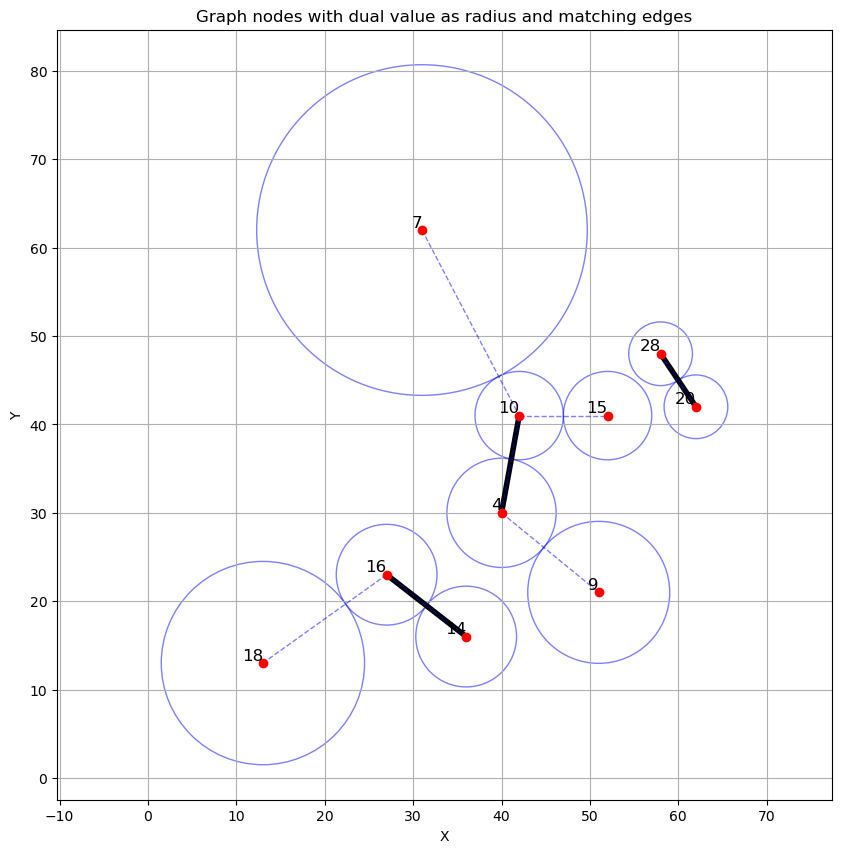

In [10]:
visualize(f,points)

In [11]:
f.root = None
f.root = [node for node in f.nodes if node.Matching == None][0]
while f.bfs(f.root) != 1:
    f.updatedual()
    visualize(f,points)

root id :  7
curnode :  7
tight nodes :  [10]
grow 10
curnode :  4
tight nodes :  [9, 10]
augment 9


root id :  15
curnode :  15
tight nodes :  [10]
grow 10
curnode :  7
tight nodes :  [10]
Grow 28


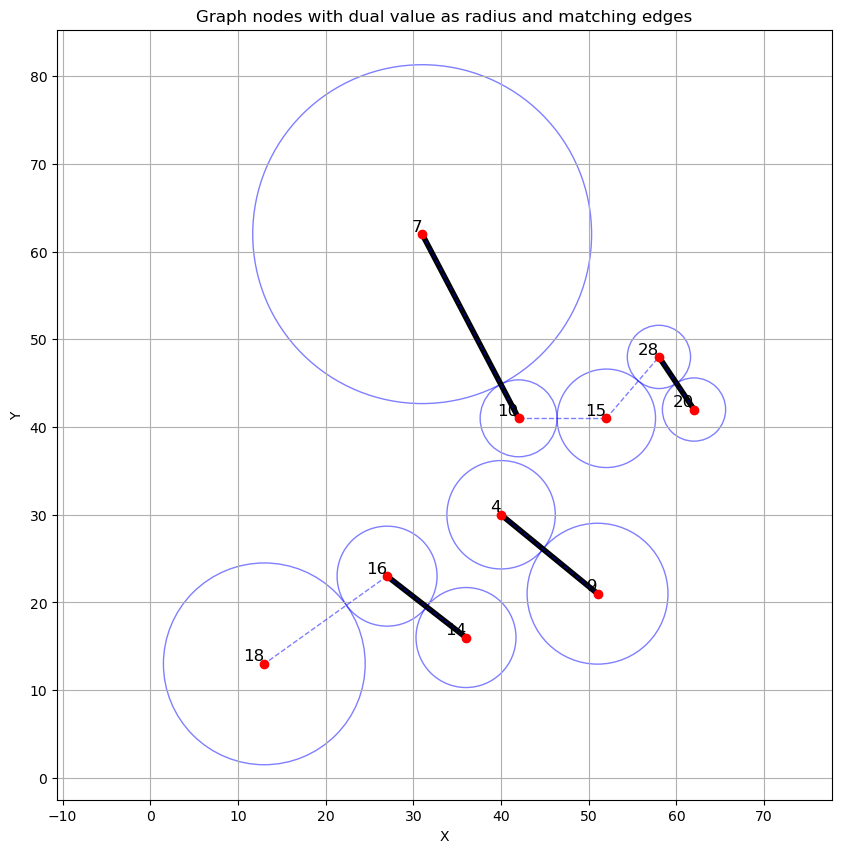

root id :  15
curnode :  15
tight nodes :  [10, 28]
grow 10
grow 28
curnode :  7
tight nodes :  [10]
curnode :  20
tight nodes :  [28]
Shrink (15, 20)


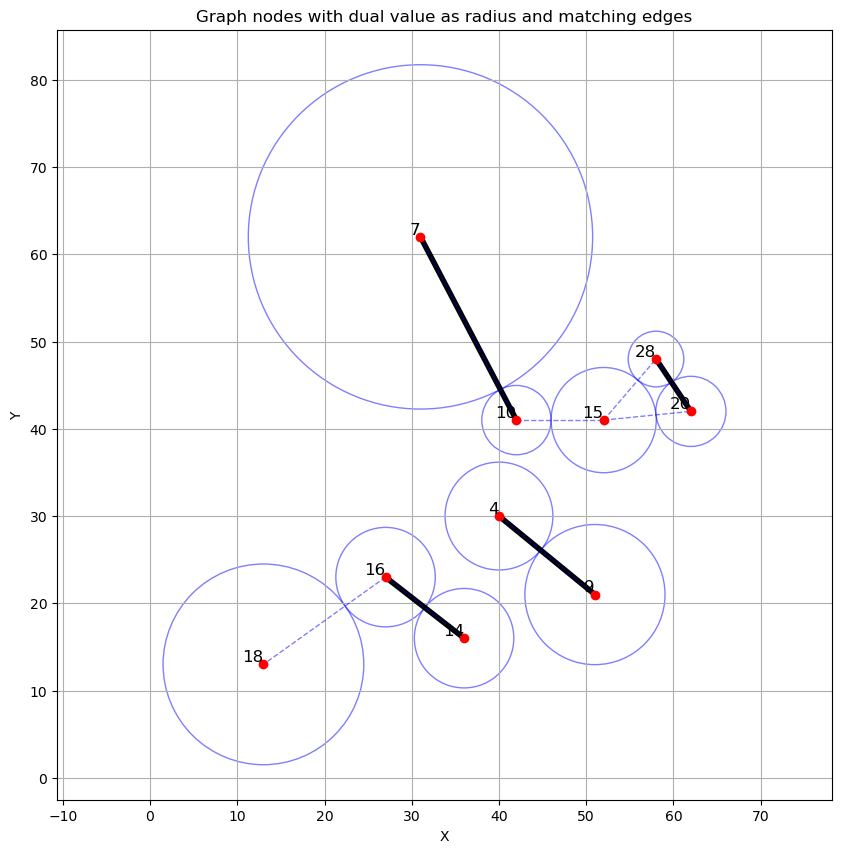

root id :  15
curnode :  15
tight nodes :  [10, 20, 28]
grow 10
grow 20
shrink
30 4 4.0693219448578575
30 7 3.9336281000898010
30 9 5.9634951147049415
30 10 0E-16
30 14 17.9516082700730700
30 16 19.0758077122601370
30 18 30.4774833642987510
30 30 -1
curnode :  7
tight nodes :  [10]
curnode :  30
tight nodes :  [10]
Shrink (7, 30)


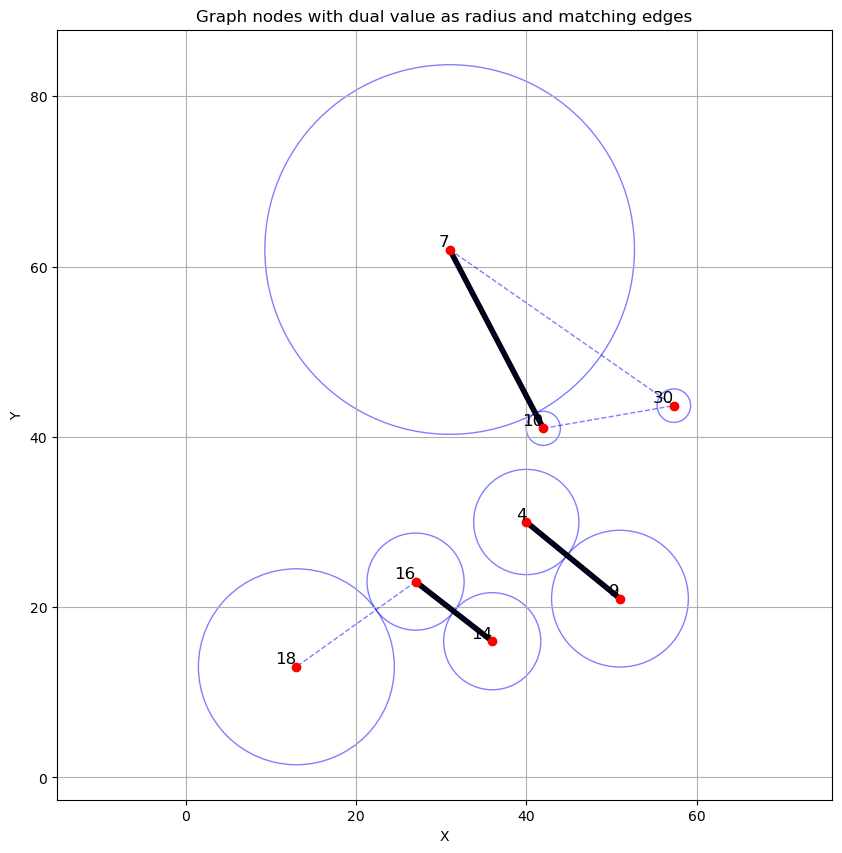

root id :  30
curnode :  30
tight nodes :  [7, 10]
grow 7
shrink
31 4 5.3586883936431800
31 9 15.8831363997280350
31 14 18.8675520834942135
31 16 11.8012024462824345
31 18 18.9952471399159905
31 31 -1
curnode :  31
tight nodes :  []
Grow 4


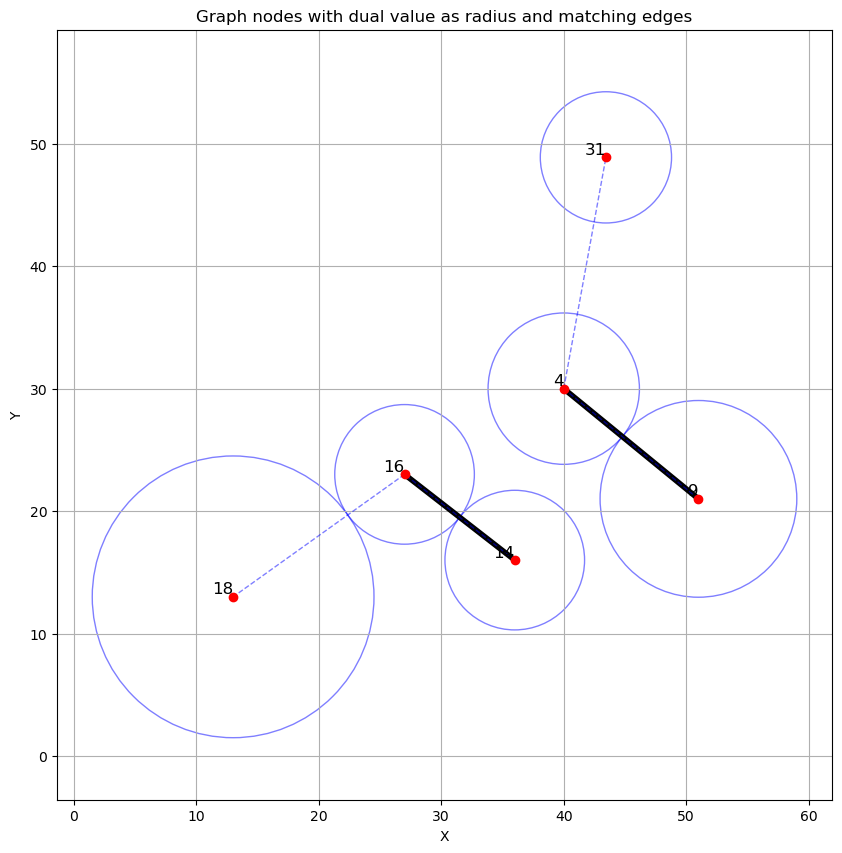

root id :  31
curnode :  31
tight nodes :  [4]
grow 4
curnode :  9
tight nodes :  [4]
Grow 14


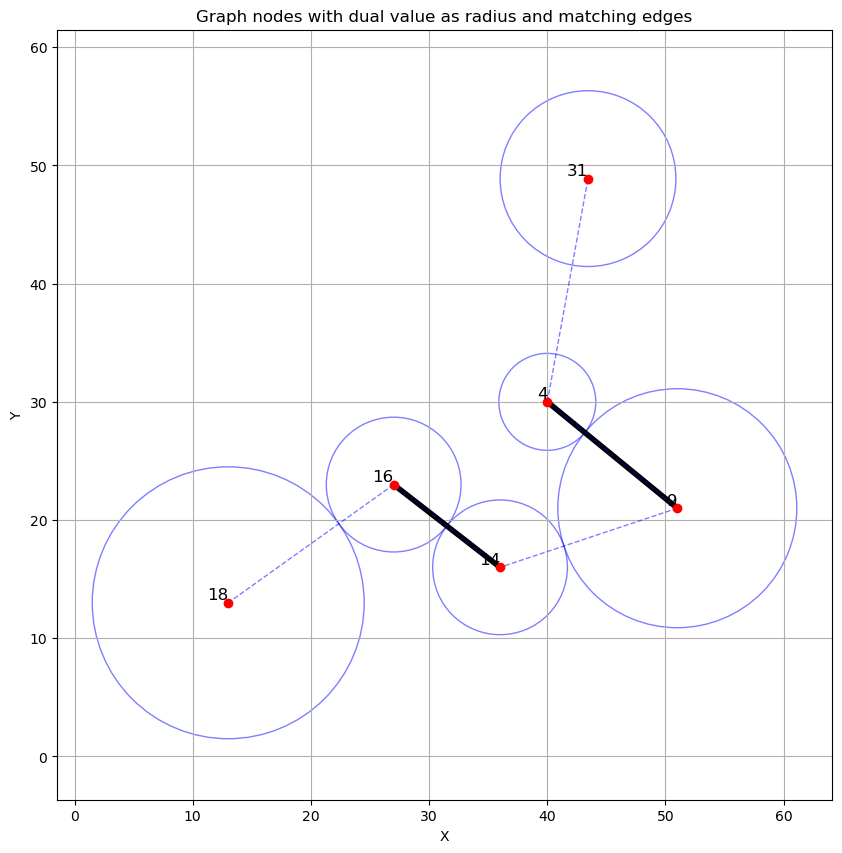

root id :  31
curnode :  31
tight nodes :  [4]
grow 4
curnode :  9
tight nodes :  [4, 14]
grow 14
curnode :  16
tight nodes :  [14, 18]
augment 18
31 blossom
31 31 4 11.5390282811421290 (<__main__.blossom object at 0x000001B7BC72F860>, <__main__.blossom object at 0x000001B7BC766FF0>, Decimal('33.241540277189323'), None)
7 is target
30 blossom
30 10 30 3.9708412362571005 (<__main__.blossom object at 0x000001B7BC767440>, <__main__.blossom object at 0x000001B7BC7679B0>, Decimal('10.000000000000000'), None)
15 is target
lifting 30 to 15
lifting 31 to 7


In [12]:
f.root = None
f.root = [node for node in f.nodes if node.Matching == None][0]
while f.bfs(f.root) != 1:
    f.updatedual()
    visualize(f,points)

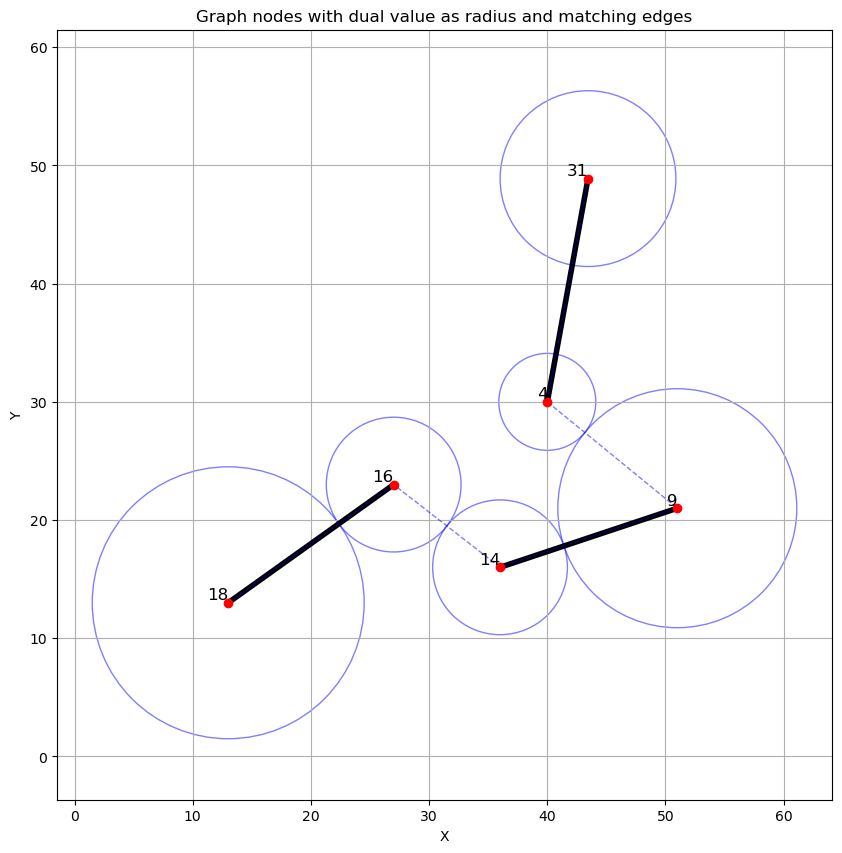

In [13]:
visualize(f,points)

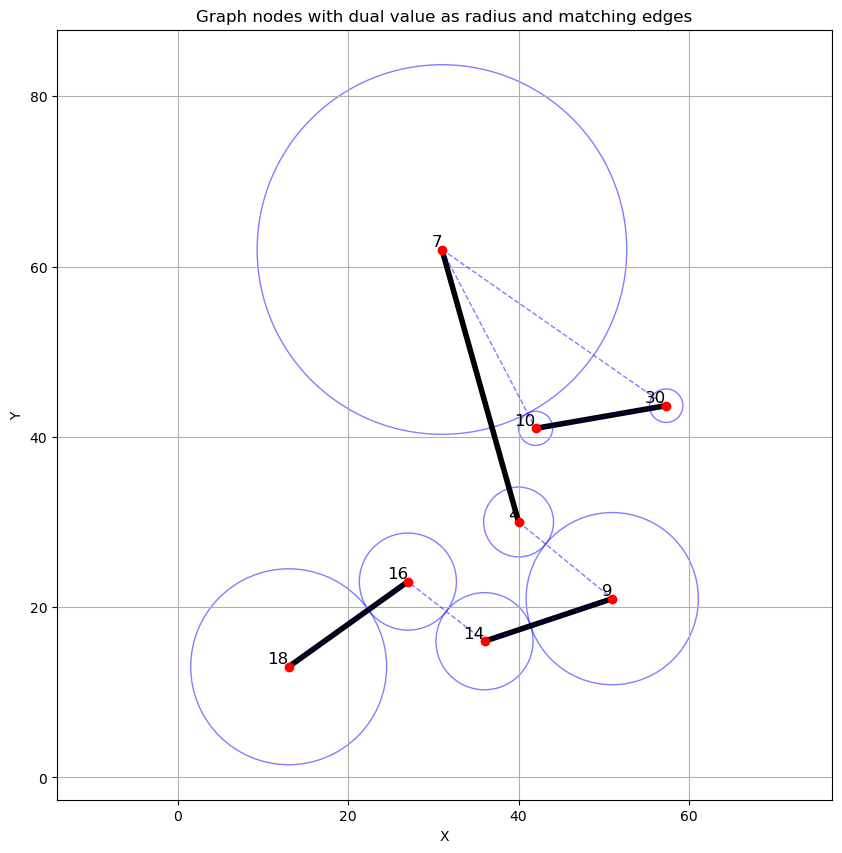

In [14]:
b = [x for x in f.nodes if x.is_blossom()][0]
f.EXPAND(b)
visualize(f,points)

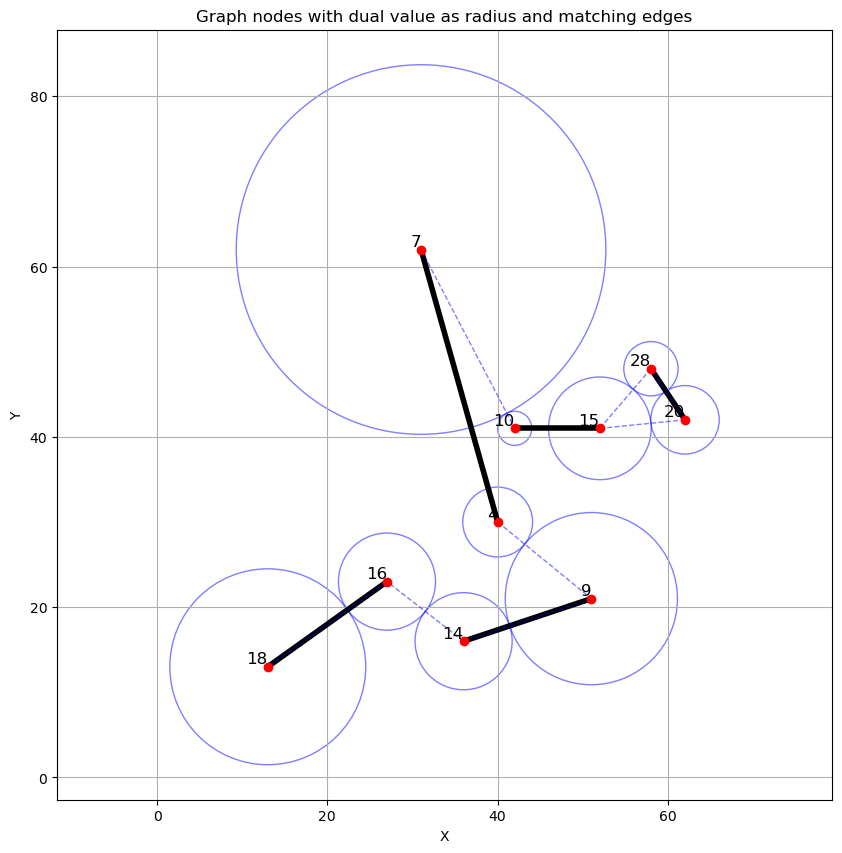

In [15]:
b = [x for x in f.nodes if x.is_blossom()][0]
f.EXPAND(b)
visualize(f,points)

In [16]:
f.root = None
f.root = [node for node in f.nodes if node.Matching == None][0]
while f.bfs(f.root) != 1:
    f.updatedual()
    visualize(f,points)

IndexError: list index out of range

In [ ]:
a = [x for x in f.nodes]

sum = 0
for b in a:
    sum += f.distance(b, b.Matching)
    print(b.Id, b.Matching.Id)
print(sum/2)

sum = 0
sum += distance_matrix[18][16]
sum += distance_matrix[14][9]
sum += distance_matrix[10][7]
sum += distance_matrix[15][4]
sum += distance_matrix[28][20]
print(sum)

In [ ]:
print(distance_matrix[4][7])
print(distance_matrix[4][15])